In [1]:
from topological_insulator import Problem
import numpy as np

In [2]:
data_path = "../../topological_insulator/data/"
file_name = "honeycomb.json"

In [3]:
def set_eigenvalues(problem: Problem, t_1, t_2, M_val, B=0):
    problem.cell_parser.field.magnetic.value = B
    subs = ["A", "B"]
    for sub_label in subs:
        parser = getattr(problem.cell_parser.eigenvalues, sub_label).value
        M = lambda label: M_val if label == "A" else -M_val
        parser["onsite_energy"][sub_label]["E_s"] = M(sub_label)
        try:
            parser["SO_coupling"][sub_label]["lambda_ss"] = t_2
        except:
            pass
        for nn_label in subs:
            if sub_label == nn_label:
                continue
            parser["nn_hopping"][nn_label]["t_ss_sigma"] = t_1

In [4]:
location = "bulk"
t_1 = -np.sqrt(2)
cases = {
    0: {"t_2": 0.07*t_1, "M": 0},
    1: {"t_2": 0, "M": 0.21*t_1},
}

In [5]:
results = {}
for n, eigenvalue_dict in enumerate(cases.values()):
    t_2 = eigenvalue_dict["t_2"]
    M = eigenvalue_dict["M"]
    print("")
    print(f"Running case for: t_2 = {t_2} and |M| = {M}")
    problem = Problem(data_path=data_path, file_name=file_name)
    set_eigenvalues(problem, t_1, t_2, M, B=0)
    problem.setup(
        N_r = 10,
        N_k = 300,
        location = location,
        BZ = "reduced"
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: t_2 = -0.09899494936611666 and |M| = 0
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: t_2 = 0 and |M| = -0.29698484809834996
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


In [6]:
band = 0

## Case 0

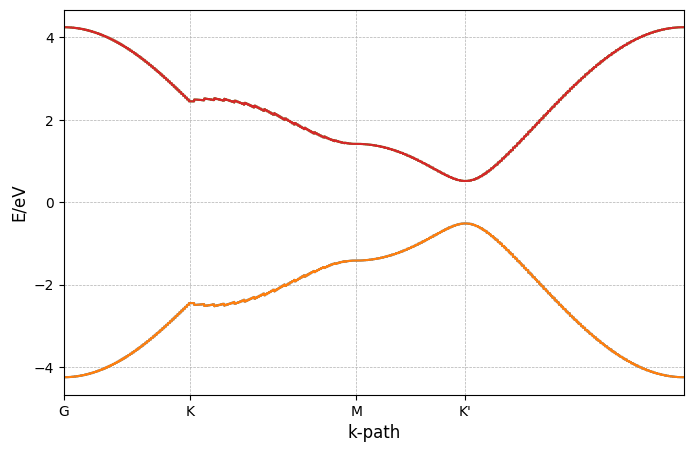

In [7]:
results[0].plot("high_symmetry", location=location)

In [10]:
if results[0].cell_parser.field.magnetic.value != 0:
    C, F, _  = results[0].get_topological_invariant(band=band)
    print(f"Chern Invariant: {np.round(C/3)}")
    results[0].plot("berry_flux", location=location, F=F)
else:
    Z2 = results[0].get_topological_invariant()
    print(f"Z2 Invariant: {Z2}")

Z2 Invariant: 1


## Case 1

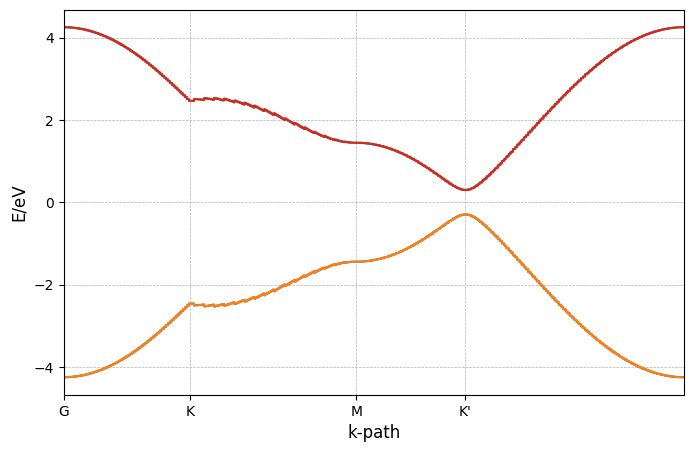

In [11]:
results[1].plot("high_symmetry", location=location, hide=True)

In [12]:
if results[1].cell_parser.field.magnetic.value != 0:
    C, F, _  = results[1].get_topological_invariant(band=band)
    print(f"Chern Invariant: {np.round(C/3)}")
    results[1].plot("berry_flux", location=location, F=F)
else:
    Z2 = results[1].get_topological_invariant(band=band)
    print(f"Z2 Invariant: {Z2}")

Z2 Invariant: 0
